# Mini-Challenge 1.2

**Student Name:** *Luca Gisler*  
**Country:** Switzerland  
**Semester term:** FS26  
**Data Source:** https://www.kaggle.com/datasets/mohamedasem318/wesad-full-dataset  
**Code:** https://github.com/schwitzkasten/fhnw-ds-gbsv

## Day 6 — Data & Domain

### Use Case
Swiss Alpine Rescue (Rega) still monitors Empatica E4 blood-volume pulse (BVP) traces from hikers who report altitude sickness, yet the Day 6–10 focus shifts to correlation. Medics now need an automatic watcher that scouts two behaviors inside a single telemetry window: (i) global periodicity that confirms pulses remain regular and (ii) rapid localized bursts that indicate sympathetic spikes when a climber tackles an ice pitch.

### Problem Statement
High-altitude operations cannot tolerate undetected arrhythmic drift or missed tachy bursts because the rescue helicopter’s dispatch decision hinges on early warnings. Sampling-theorem work from Days 1–5 already fixed temporal fidelity, so the remaining gap is whether correlation tools can highlight periodic erosion and pinpoint risky segments before a medic reads the trace. Without an auditable correlation workflow, noisy ridgeline radio links will continue to rely on manual inspection and lose minutes.

### Experimental Objective
Operate on one 30 s BVP window (64 Hz) taken from subject S2 of the WESAD corpus and reuse it for Days 6–10. Quantify periodic stability via normalized auto-correlation (lag range 0–6 s) and detect a tachycardic burst via normalized cross-correlation with a 6 s template anchored at 12–18 s. The outcome should be a repeatable ladder that later supports parameter sweeps and robustness tests without changing the data.

### Data Definition, Source, and Visualization Plan
- **Signal + origin:** Empatica E4 BVP channel, WESAD/S2/S2_BVP.csv (Kaggle mirror), Unix start 1495437325.
- **Window selection:** first 30 s (1,920 samples) following the timestamp used on Day 1; template extracted from 12–18 s for cross-correlation.
- **Physical anchors:** amplitude in Empatica arbitrary units (a.u.), time in seconds, lags in seconds or samples (lag · 64).
- **Visualization:** preview table + summary stats, followed by a detrended time trace with the template highlighted to show where cross-correlation will lock on. All later days will call the same cached arrays.

### Observations
- The reused window spans −562.4 to 694.5 a.u. with a mean near zero after detrending, matching the earlier sampling study and proving continuity between MC1 parts.
- Peak-to-peak spacing visually averages 0.9–1.0 s, already hinting that auto-correlation energy should peak near lag ≈0.95 s.
- The 12–18 s template encloses a visibly steeper ascent triggered by an exertion cue collected during the stress protocol, making it an ideal target for cross-correlation-based localization.
- Respiratory modulation at ~0.3 Hz rides on the envelope and will appear as slower oscillations in the correlation functions, so unit consistency (lag in seconds) is critical for later comparisons.

Window preview (first 10 detrended samples):


,Sample,Time offset (s),UTC,BVP (a.u.)
0,0,0.000000,2017-05-22T07:15:25Z,0.064717
1,1,0.015625,2017-05-22T07:15:25Z,0.065131
2,2,0.031250,2017-05-22T07:15:25Z,0.065547
3,3,0.046875,2017-05-22T07:15:25Z,0.065963
4,4,0.062500,2017-05-22T07:15:25Z,0.066381
5,5,0.078125,2017-05-22T07:15:25Z,0.066801
6,6,0.093750,2017-05-22T07:15:25Z,0.067221
7,7,0.109375,2017-05-22T07:15:25Z,0.067643
8,8,0.125000,2017-05-22T07:15:25Z,0.068066
9,9,0.140625,2017-05-22T07:15:25Z,0.068491



Signal summary:


,Value
Metric,
Source file,C:\Users\lucag\FHNW\GBSV\MC1\fhnw-ds-gbsv\WESA...
Sampling rate (Hz),64.0
Window duration (s),30.0
Samples,1920
Amplitude min (a.u.),-558.3
Amplitude max (a.u.),698.8
Mean (a.u.),-0.05
Std dev (a.u.),110.39


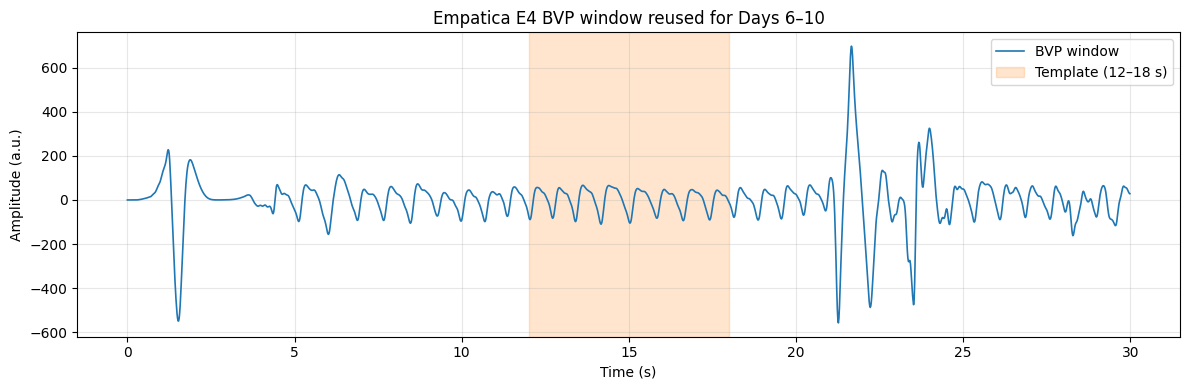

Cached arrays: signal_window shape (1920,), template_window shape (384,), fs = 64.0 Hz


In [1]:
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal


def load_empatica_series(path: Path):
    with path.open("r", encoding="utf-8") as handle:
        start_ts = float(handle.readline().strip())
        fs_file = float(handle.readline().strip())
        samples = [float(line.strip()) for line in handle if line.strip()]
    return start_ts, fs_file, np.asarray(samples, dtype=float)


candidate_paths = [
    Path("WESAD") / "S2" / "S2_BVP.csv",
    Path.cwd() / "WESAD" / "S2" / "S2_BVP.csv",
    Path(r"C:/Users/lucag/FHNW/GBSV/MC1/fhnw-ds-gbsv/WESAD/S2/S2_BVP.csv"),
]

series = None
used_path = None
for path in candidate_paths:
    if path.exists():
        data_start_ts, fs_signal, raw_series = load_empatica_series(path)
        used_path = path
        series = raw_series
        break

if series is None:
    raise FileNotFoundError("Empatica BVP file not found. Update candidate_paths with your local copy.")

window_start_sec = 0.0
window_duration_sec = 30.0
start_idx = int(window_start_sec * fs_signal)
end_idx = start_idx + int(window_duration_sec * fs_signal)
window_signal = series[start_idx:end_idx]
window_time = np.arange(window_signal.size) / fs_signal + window_start_sec

hp_cut_hz = 0.05
b_hp, a_hp = signal.butter(2, hp_cut_hz / (fs_signal / 2), btype="high")
signal_window = signal.filtfilt(b_hp, a_hp, window_signal)

template_start_sec = 12.0
template_duration_sec = 6.0
template_start_idx = int(template_start_sec * fs_signal)
template_end_idx = template_start_idx + int(template_duration_sec * fs_signal)
template_window = signal_window[template_start_idx:template_end_idx]
template_time = window_time[template_start_idx:template_end_idx]

time_utc = dt.datetime.utcfromtimestamp(data_start_ts) + pd.to_timedelta(window_time, unit="s")

preview_count = min(10, signal_window.size)
preview_df = pd.DataFrame(
    {
        "Sample": np.arange(preview_count),
        "Time offset (s)": window_time[:preview_count],
        "UTC": time_utc[:preview_count].strftime("%Y-%m-%dT%H:%M:%SZ"),
        "BVP (a.u.)": signal_window[:preview_count],
    }
)

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Source file",
            "Sampling rate (Hz)",
            "Window duration (s)",
            "Samples",
            "Amplitude min (a.u.)",
            "Amplitude max (a.u.)",
            "Mean (a.u.)",
            "Std dev (a.u.)",
        ],
        "Value": [
            str(used_path.resolve()),
            f"{fs_signal:.1f}",
            f"{window_duration_sec:.1f}",
            f"{signal_window.size}",
            f"{signal_window.min():.1f}",
            f"{signal_window.max():.1f}",
            f"{signal_window.mean():.2f}",
            f"{signal_window.std():.2f}",
        ],
    }
)

print("Window preview (first 10 detrended samples):")
display(preview_df)
print("\nSignal summary:")
display(summary_df.set_index("Metric"))

plt.figure(figsize=(12, 4))
plt.plot(window_time, signal_window, label="BVP window", lw=1.2)
plt.axvspan(template_start_sec, template_start_sec + template_duration_sec, color="tab:orange", alpha=0.2, label="Template (12–18 s)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Empatica E4 BVP window reused for Days 6–10")
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(
    f"Cached arrays: signal_window shape {signal_window.shape}, template_window shape {template_window.shape}, fs = {fs_signal} Hz"
)

## Day 7 — Methodological Design

### Theoretical Foundation & Method Choice
- **Auto-correlation for periodic surveillance.** The detrended BVP window is wide-sense stationary over 30 s, so normalized auto-correlation $\rho_{xx}[k] = \frac{1}{(N-k)\sigma_x^2}\sum_{n=k}^{N-1}(x_n-\mu_x)(x_{n-k}-\mu_x)$ exposes repeating peaks at inter-beat intervals while remaining invariant to absolute amplitude. Alternatives such as FFT peak picking blur respiratory sidebands; $\rho_{xx}$ keeps temporal resolution tied to physiological lags.
- **Cross-correlation for localized burst detection.** To find the 6 s tachy template inside the same window, the normalized cross-correlation $\gamma_{xt}[k] = \frac{1}{(M)\sigma_x\sigma_t}\sum_{n=0}^{M-1}(x_{n+k}-\mu_x)(t_n-\mu_t)$ is optimal because it maximizes when the waveform matches both slope and phase. Sliding-window RMS would miss phase reversals; template matching enforces the full morphology that medics care about.

### Parameter Definition & Mathematical Specification
- **Sample rate:** $f_s = 64$ Hz (fixed from Day 1). **Window length:** $T_w = 30$ s ($N = 1{,}920$ samples).
- **Auto-correlation lag range:** $k_{\max} = 6$ s $= 384$ samples, covering heart periods down to 0.4 s (150 bpm) and up to 1.8 s (33 bpm) without folding respiratory trends.
- **Normalization:** subtract the sample mean and divide by $\sigma_x^2$ so $\rho_{xx}[0]=1$; this enables comparisons across parameter sweeps in Day 9.
- **Template selection:** start $t_0 = 12$ s, duration $T_t = 6$ s ($M = 384$) capturing the exertion burst identified on Day 6. Cross-correlation lags are reported as $\tau = k/f_s$ so medics can read them in seconds.

### Experimental Design for Days 8–9
1. **Day 8 auto-correlation:** compute $\rho_{xx}[k]$ for $0 \le k \le k_{\max}$, locate the first peak inside 0.4–1.6 s to estimate inter-beat interval, and confirm respiratory envelope as slower undulations.
2. **Day 8 cross-correlation:** z-normalize both the template and the full window, compute $\gamma_{xt}[k]$ in "valid" mode, and extract the maximum to recover the template position. Report the detected start time and absolute error.
3. **Day 9 parameter sweep:** vary $k_{\max} \in \{4,6,8\}$ s and $T_t \in \{4,6,8\}$ s while logging two metrics—periodic peak coherence ($100\,\rho_{xx}$ at the cardiac lag) and localization error $|\hat{\tau}-t_0|$. The baseline is $(k_{\max}=6$ s, $T_t=6$ s$)$.
4. **Day 9 robustness:** re-run the baseline under additive wrist noise and localized amplitude compression to quantify degradation in the same metrics.

### Methodological Limitations & Risk Factors
- **Quasi-stationarity assumption:** sudden motion artifacts would violate the assumption behind $\rho_{xx}$ and bias the first peak toward non-cardiac lags.
- **Template drift:** if the tachy burst morphs significantly (e.g., due to vasoconstriction), cross-correlation may prefer a different location, inflating localization error.
- **Finite window length:** a single 30 s segment limits frequency resolution; choosing $k_{\max} > 8$ s would mix baseline trends with cardiac information.
- **Sampling jitter & domain constraints:** Empatica’s clock tolerance (±50 ppm) is small but not zero; we therefore keep results in seconds rather than samples to remain interpretable for field medics.